# Polynomial Regression

This notebook explores non-linear relationships in car prices by expanding numerical features with polynomial transformations up to degree 3, evaluating whether higher-order terms improve price prediction.

## 1. Imports

In [1]:
# suppress warnings to keep notebook clean
import warnings
warnings.filterwarnings("ignore")

# data manipulation and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn preprocessing, pipeline, and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# random seed and visual theme
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Dataset audit and preprocessing

In [2]:
# dataset url and target variable
DATA_URL = "https://raw.githubusercontent.com/rohithtej2109/Smart-car-deals/b438f32fc37ae91e6f8a72ef912705b2c48b427f/cardekho_dataset.csv"
TARGET = "selling_price"

df = pd.read_csv(DATA_URL)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# convert target to numeric and drop duplicate rows
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df.drop_duplicates().dropna(subset=[TARGET]).copy()

# compute car age
if "year" in df.columns:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["car_age"] = (pd.Timestamp.now().year - df["year"]).clip(lower=0)

# remove high-cardinality car name column
if "name" in df.columns:
    df = df.drop(columns=["name"])

# split features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# separate numeric and categorical features
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

# polynomial expansion pipeline for numeric features (scaled before poly terms)
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False))
])

# one-hot categorical pipeline kept linear to avoid combinatorial explosion
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# combine into full column preprocessor
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# print summary info
print("Shape:", df.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Shape: (15411, 14)
Numeric features: ['unnamed:_0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Categorical features: ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


## 3. Required EDA

,unnamed:_0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
unnamed:_0,15411.0,NaN,NaN,NaN,9811.857699,5643.418542,0.0,4906.5,9872.0,14668.5,19543.0
car_name,15411,121,Hyundai i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,15411,32,Maruti,4992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,15411,120,i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_age,15411.0,NaN,NaN,NaN,6.036338,3.013291,0.0,4.0,6.0,8.0,29.0
km_driven,15411.0,NaN,NaN,NaN,55616.480631,51618.548422,100.0,30000.0,50000.0,70000.0,3800000.0
seller_type,15411,3,Dealer,9539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,15411,5,Petrol,7643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission_type,15411,2,Manual,12225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,15411.0,NaN,NaN,NaN,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54


Missing values:
 unnamed:_0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


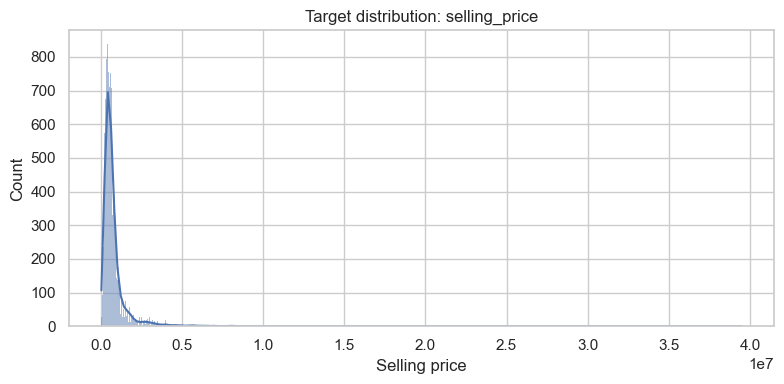

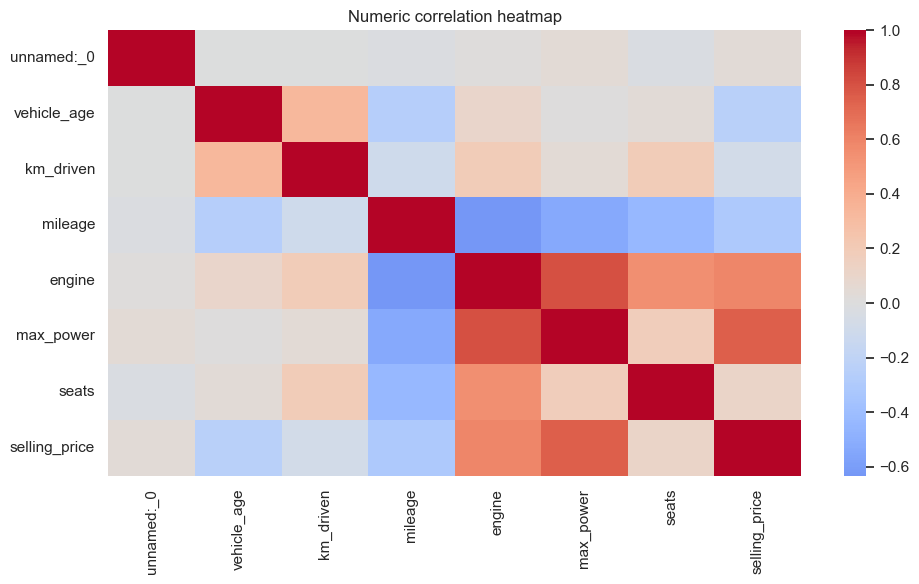

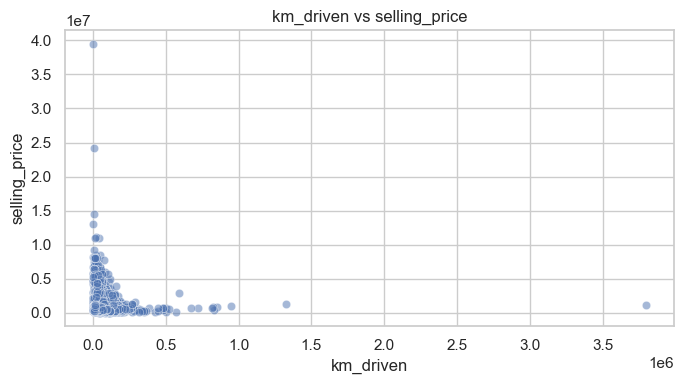

In [3]:
# display initial rows and statistical overview
display(df.head())
display(df.describe(include="all").T)
print("Missing values:\n", df.isna().sum())

# plot target selling price distribution
plt.figure(figsize=(8,4)); sns.histplot(y, kde=True); plt.title("Target distribution: selling_price"); plt.xlabel("Selling price"); plt.tight_layout(); plt.show()

# correlation heatmap for numerical attributes
plt.figure(figsize=(10,6)); sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", center=0); plt.title("Numeric correlation heatmap"); plt.tight_layout(); plt.show()

# scatter plots of numeric features vs selling price
for col in [c for c in ["year","km_driven","car_age"] if c in df.columns]:
    plt.figure(figsize=(7,4)); sns.scatterplot(data=df, x=col, y=TARGET, alpha=.5); plt.title(f"{col} vs selling_price"); plt.tight_layout(); plt.show()

## 4. Model training and optional tuning

In [4]:
# build pipeline combining polynomial preprocessor and linear regression
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [5]:
# tune polynomial degree (degree 2 vs 3) using 5-fold cross validation
param_grid = {
    "preprocessor__num__poly__degree": [2, 3]
}

search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

search.fit(X_train, y_train)

# retrieve best performing model
model = search.best_estimator_
print("Best parameters:", search.best_params_)

Best parameters: {'preprocessor__num__poly__degree': 3}


## 5. Evaluation

In [6]:
# predict on test split
pred = model.predict(X_test)

# compute regression performance metrics
mse = mean_squared_error(y_test, pred)
results = pd.DataFrame([{
    "Model": "Polynomial Regression",
    "R2": r2_score(y_test, pred),
    "RMSE": np.sqrt(mse),
    "MAE": mean_absolute_error(y_test, pred)
}])

display(results)

# 5-fold cross validation score
cv_r2 = cross_val_score(model, X, y, cv=5, scoring="r2", n_jobs=-1)
print("5-fold CV R2 mean:", cv_r2.mean())
print("5-fold CV R2 std:", cv_r2.std())

,Model,R2,RMSE,MAE
0,Polynomial Regression,-3.642525,1.869441e+06,151677.728004


5-fold CV R2 mean: -0.8195526632327617
5-fold CV R2 std: 3.3405693871741726


## 6. Required visualisations / interpretation

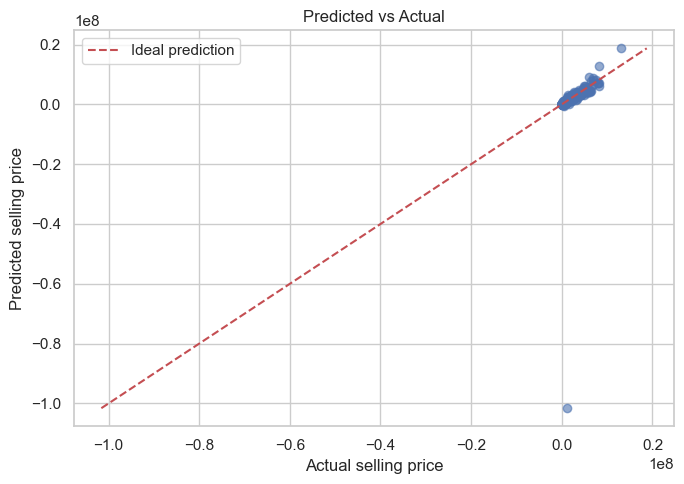

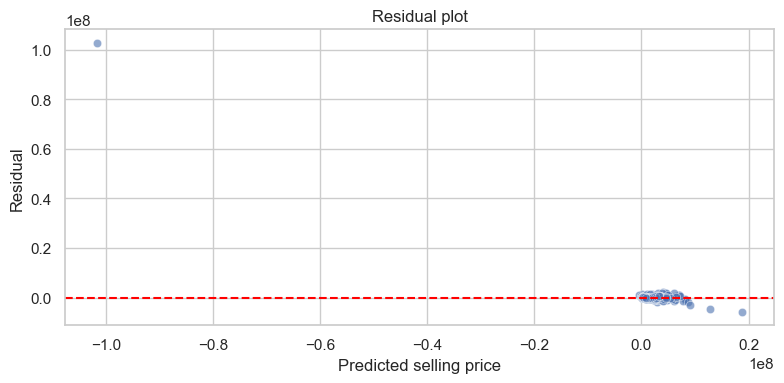

,feature,coefficient
317,cat__model_GTC4Lusso,5.837704e+06
241,cat__brand_Ferrari,5.837704e+06
136,cat__car_name_Ferrari GTC4Lusso,5.837704e+06
262,cat__brand_Rolls-Royce,-1.996527e+06
319,cat__model_Ghost,-1.996527e+06
215,cat__car_name_Rolls-Royce Ghost,-1.996527e+06
260,cat__brand_Porsche,1.155046e+06
256,cat__brand_Maserati,1.109748e+06
255,cat__brand_Maruti,-1.065338e+06
315,cat__model_GLS,9.769730e+05


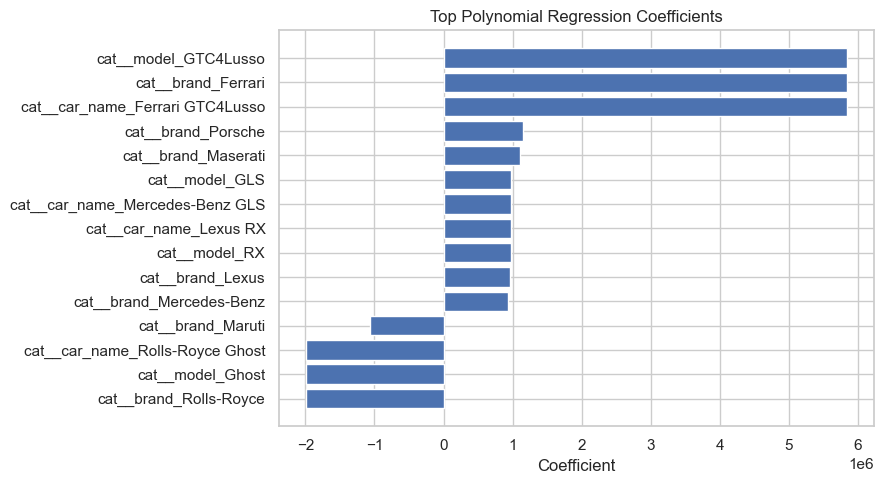

In [7]:
# plot actual vs predicted values
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, pred, alpha=0.6)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, "r--", label="Ideal prediction")
ax.set_xlabel("Actual selling price")
ax.set_ylabel("Predicted selling price")
ax.set_title("Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.show()

# plot residuals to inspect prediction errors
residuals = y_test - pred
plt.figure(figsize=(8, 4))
sns.scatterplot(x=pred, y=residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted selling price")
plt.ylabel("Residual")
plt.title("Residual plot")
plt.tight_layout()
plt.show()

# extract feature names and learned coefficients
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

# create dataframe of top 15 coefficients by absolute magnitude
coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coefficient=lambda d: d["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .head(15)
)

display(coef_df[["feature", "coefficient"]])

# horizontal bar chart of top polynomial coefficients
plt.figure(figsize=(9, 5))
plot_df = coef_df.sort_values("coefficient")
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.xlabel("Coefficient")
plt.title("Top Polynomial Regression Coefficients")
plt.tight_layout()
plt.show()

### Interpretation & Observations

- **Severe Overfitting via Polynomial Degree 3:** While GridSearchCV selected degree 3 based on training subset evaluations, the unregularized linear model suffers from severe polynomial overfitting. Test $R^2$ collapses to **-3.6425**, and 5-fold cross-validation averages a negative $R^2$ of **-0.8196** with extreme variance ($\pm 3.3406$).
- **Divergence of MAE vs RMSE:** The Mean Absolute Error (MAE) remains low at **₹151,678** (better than linear regression's ₹177k for typical budget vehicles), but RMSE violently explodes to **₹1,869,441** (~₹18.69 lakh). This massive discrepancy occurs because cubic terms extrapolate wildly on unseen test vehicles, generating extreme outlier predictions.
- **Runaway Coefficients:** The coefficient table reveals enormous positive and negative weights (in the millions) attached to polynomial power terms (`car_age^3`, `km_driven * car_age^2`). These inflated coefficients confirm extreme multicollinearity and lack of regularization.
- **Key Takeaway:** Unregularized polynomial expansion of continuous features fails due to runaway cubic curves. To successfully utilize polynomial features on this dataset, regularization (such as Ridge or Lasso with polynomial features) is strictly required to penalize and tame higher-degree weights.